In [1]:
from neuralhydrology.utils.config import Config
from neuralhydrology.utils.DCFE_utils import get_dcfe_params
from neuralhydrology.datautils import utils
from pathlib import Path
import torch
from neuralhydrology.nh_run import start_run

## Format HydroAtlas Basin Attributes

## Simple LSTM for AORC

In [23]:
# by default we assume that you have at least one CUDA-capable NVIDIA GPU
if torch.cuda.is_available():
    print("GPU")
    start_run(config_file=Path("2basin_lstmDaily_AORC.yml"))

# fall back to CPU-onl y mode
else:
    print("CPU")
    start_run(config_file=Path("2basin_lstmDaily_AORC.yml"), gpu=-1)

CPU
2025-09-04 14:12:49,104: Logging to /Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology/examples/07-DifferentialCFE-Model/runs/testLSTM_AORC_run_0409_141249/output.log initialized.
2025-09-04 14:12:49,105: ### Folder structure created at /Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology/examples/07-DifferentialCFE-Model/runs/testLSTM_AORC_run_0409_141249
2025-09-04 14:12:49,105: ### Run configurations for testLSTM_AORC_run
2025-09-04 14:12:49,106: experiment_name: testLSTM_AORC_run
2025-09-04 14:12:49,106: train_basin_file: 2_basin.txt
2025-09-04 14:12:49,107: validation_basin_file: 2_basin.txt
2025-09-04 14:12:49,107: test_basin_file: 2_basin.txt
2025-09-04 14:12:49,108: train_start_date: 1989-10-01 00:00:00
2025-09-04 14:12:49,108: train_end_date: 1995-09-30 00:00:00
2025-09-04 14:12:49,108: validation_start_date: 1995-10-01 00:00:00
2025-09-04

/Users/ziyu/miniconda3/envs/dCFE_env/lib/python3.12/site-packages/neuralhydrology/modelzoo/__init__.py:74: FutureWarning: The `LSTM` class has been renamed to `CustomLSTM`. Support for `LSTM` will we dropped in the future.
  warnings.warn(


# Epoch 1: 100%|██████████| 8/8 [00:16<00:00,  2.03s/it, Loss: 0.3847]
2025-09-04 14:13:05,617: Epoch 1 average loss: avg_loss: 0.62677, avg_total_loss: 0.62677
# Epoch 2: 100%|██████████| 8/8 [00:06<00:00,  1.31it/s, Loss: 0.2496]
2025-09-04 14:13:11,731: Epoch 2 average loss: avg_loss: 0.57517, avg_total_loss: 0.57517
# Epoch 3: 100%|██████████| 8/8 [00:06<00:00,  1.32it/s, Loss: 0.2714]
2025-09-04 14:13:17,797: Epoch 3 average loss: avg_loss: 0.51279, avg_total_loss: 0.51279
# Validation: 100%|██████████| 1/1 [00:01<00:00,  1.28s/it]
2025-09-04 14:13:19,318: Epoch 3 average validation loss: 0.24474 -- Median validation metrics: avg_loss: 0.24474, NSE: 0.03560
# Epoch 4: 100%|██████████| 8/8 [00:06<00:00,  1.22it/s, Loss: 0.7450]
2025-09-04 14:13:25,882: Epoch 4 average loss: avg_loss: 0.52703, avg_total_loss: 0.52703
# Epoch 5: 100%|██████████| 8/8 [00:06<00:00,  1.32it/s, Loss: 0.1251]
2025-09-04 14:13:31,963: Epoch 5 average loss: avg_loss: 0.49482, avg_total_loss: 0.49482
# Epoch

In [24]:
from neuralhydrology.evaluation import metrics, get_tester
import pandas as pd
from neuralhydrology.utils.config import Config
import matplotlib.pyplot as plt
### Run configurations for testLSTM_AORC_run
run_dir = Path("runs/testLSTM_AORC_run_0409_141249")
run_config = Config(run_dir / "config.yml")

# create a tester instance and start evaluation
tester = get_tester(cfg=Config(run_dir / "config.yml"), run_dir=run_dir, period="test", init_model=True)
results = tester.evaluate(save_results=True, metrics=run_config.metrics)

2025-09-04 14:14:25,390: Using the model weights from runs/testLSTM_AORC_run_0409_141249/model_epoch010.pt


/Users/ziyu/miniconda3/envs/dCFE_env/lib/python3.12/site-packages/neuralhydrology/modelzoo/__init__.py:74: FutureWarning: The `LSTM` class has been renamed to `CustomLSTM`. Support for `LSTM` will we dropped in the future.
  warnings.warn(


# Evaluation: 100%|██████████| 2/2 [00:01<00:00,  1.85it/s]
2025-09-04 14:14:26,477: Stored metrics at runs/testLSTM_AORC_run_0409_141249/test/model_epoch010/test_metrics.csv
2025-09-04 14:14:26,478: Stored results at runs/testLSTM_AORC_run_0409_141249/test/model_epoch010/test_results.p


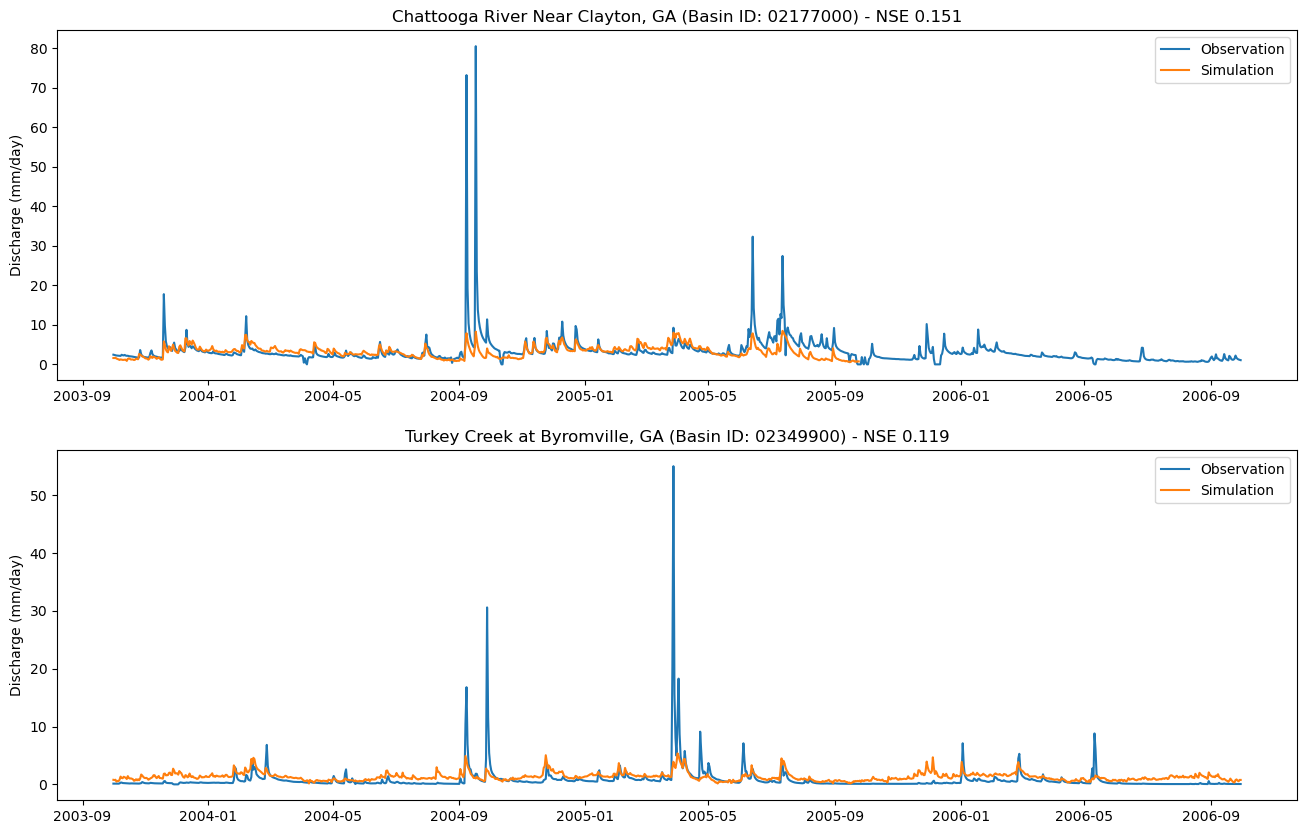

In [40]:
import numpy as np
import matplotlib.pyplot as plt


fig, ax = plt.subplots(2, 1, figsize=(16,10))
# 1) Slice by date (ISO format)
daily_xr = results["02177000"]["1D"]["xr"].sel(date=slice("2003-10", None))

ax[0].plot(daily_xr['date'], daily_xr["QObs_mm_per_day_obs"], label="Observation")
ax[0].plot(daily_xr['date'], daily_xr["QObs_mm_per_day_sim"], label="Simulation")
ax[0].set_ylabel("Discharge (mm/day)")
ax[0].set_title(f"Chattooga River Near Clayton, GA (Basin ID: 02177000) - NSE {results['02177000']['1D']['NSE']:.3f}")
ax[0].legend()


# 1) Slice by date (ISO format)
daily_xr = results["02349900"]["1D"]["xr"].sel(date=slice("2003-10", None))

ax[1].plot(daily_xr['date'], daily_xr["QObs_mm_per_day_obs"], label="Observation")
ax[1].plot(daily_xr['date'], daily_xr["QObs_mm_per_day_sim"], label="Simulation")

ax[1].set_ylabel("Discharge (mm/day)")
ax[1].set_title(f"Turkey Creek at Byromville, GA (Basin ID: 02349900) - NSE {results['02349900']['1D']['NSE']:.3f}")
ax[1].legend()

plt.show()


In [46]:
daily_xr = results["02177000"]["1D"]["xr"].sel(date=slice("2005-09-24", None))

# Which entries are NaN
nan_mask = daily_xr["QObs_mm_per_day_sim"].isnull()

# Print count
print("Total NaNs:", nan_mask.sum().item())
daily_xr["QObs_mm_per_day_sim"]

Total NaNs: 371


<xarray.DataArray 'QObs_mm_per_day_sim' (date: 372, time_step: 1)> Size: 1kB
array([[0.7421533],
       [      nan],
       [      nan],
       [      nan],
       [      nan],
       [      nan],
       [      nan],
       [      nan],
       [      nan],
       [      nan],
       [      nan],
       [      nan],
       [      nan],
       [      nan],
       [      nan],
       [      nan],
       [      nan],
       [      nan],
       [      nan],
       [      nan],
...
       [      nan],
       [      nan],
       [      nan],
       [      nan],
       [      nan],
       [      nan],
       [      nan],
       [      nan],
       [      nan],
       [      nan],
       [      nan],
       [      nan],
       [      nan],
       [      nan],
       [      nan],
       [      nan],
       [      nan],
       [      nan],
       [      nan],
       [      nan]], dtype=float32)
Coordinates:
  * date       (date) datetime64[ns] 3kB 2005-09-24 2005-09-25 ... 2006-09-30
  * time_step  (time_step) int64 8B 0

## AORC for NH-dCFE

In [4]:
# Grab config file so we can see if the code works
#config_path = Path('/Users/danielmckenzie/Documents/Active_Research/Ziyu/neuralhydrology/neuralhydrology/examples/07-DifferentialCFE-Model/2basinTest_devMultiBasin.yml')
config_path = Path('/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology/examples/07-DifferentialCFE-Model/2basin_AORC.yml')
config = Config(config_path, dev_mode=True)
basins = utils.load_basin_file(getattr(config, "train_basin_file"))

testDF = get_dcfe_params(config)
testDF.loc['02177000']
#testDF.loc['02349900']

depth                                                        tensor(2.)
bb                                                       tensor(1.8747)
satdk                                                    tensor(0.0007)
satpsi                                                   tensor(0.1889)
slop                                                     tensor(0.8340)
smcmax                                                   tensor(0.2987)
wltsmc                                                   tensor(0.0521)
D                                                            tensor(2.)
mult                                                         tensor(1.)
catchment_area_km2                                     tensor(111.1100)
refkdt                                                   tensor(0.8883)
max_gw_storage                                           tensor(0.2016)
expon                                                    tensor(1.8009)
Cgw                                                      tensor(

In [5]:
# by default we assume that you have at least one CUDA-capable NVIDIA GPU
if torch.cuda.is_available():
    print("GPU")
    start_run(config_file=Path("2basin_AORC.yml"))

# fall back to CPU-onl y mode
else:
    print("CPU")
    start_run(config_file=Path("2basin_AORC.yml"), gpu=-1)

CPU
2025-08-18 14:40:49,838: Logging to /Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology/examples/07-DifferentialCFE-Model/runs/DevMultiBasin_Test_1808_144049/output.log initialized.
2025-08-18 14:40:49,842: ### Folder structure created at /Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology/examples/07-DifferentialCFE-Model/runs/DevMultiBasin_Test_1808_144049
2025-08-18 14:40:49,842: ### Run configurations for DevMultiBasin_Test
2025-08-18 14:40:49,844: experiment_name: DevMultiBasin_Test
2025-08-18 14:40:49,844: train_basin_file: 2_basin.txt
2025-08-18 14:40:49,844: validation_basin_file: 2_basin.txt
2025-08-18 14:40:49,844: test_basin_file: 2_basin.txt
2025-08-18 14:40:49,845: train_start_date: 2000-10-01 00:00:00
2025-08-18 14:40:49,845: train_end_date: 2010-09-30 00:00:00
2025-08-18 14:40:49,845: validation_start_date: 1992-09-30 00:00:00
2025-0

In [8]:
Result_xr_1

<xarray.Dataset> Size: 12kB
Dimensions:              (date: 2, time_step: 365)
Coordinates:
  * date                 (date) datetime64[ns] 16B 2000-09-29 2000-09-30
  * time_step            (time_step) int64 3kB -364 -363 -362 -361 ... -2 -1 0
    datetime             (time_step) datetime64[ns] 3kB 1999-10-01 ... 2000-0...
Data variables:
    QObs_mm_per_day_obs  (date, time_step) float32 3kB 1.029 0.8201 ... 0.6195
    QObs_mm_per_day_sim  (date, time_step) float32 3kB nan nan nan ... nan nan

2025-08-18 15:02:40,457: Using the model weights from runs/DevMultiBasin_Test_1808_144049/model_epoch003.pt
Metrics for 1D are calculated over last 1 elements only. Ignoring 364 predictions per sequence.
# Evaluation: 100%|██████████| 2/2 [00:00<00:00,  3.40it/s]
2025-08-18 15:02:41,050: Stored metrics at runs/DevMultiBasin_Test_1808_144049/test/model_epoch003/test_metrics.csv
2025-08-18 15:02:41,051: Stored results at runs/DevMultiBasin_Test_1808_144049/test/model_epoch003/test_results.p


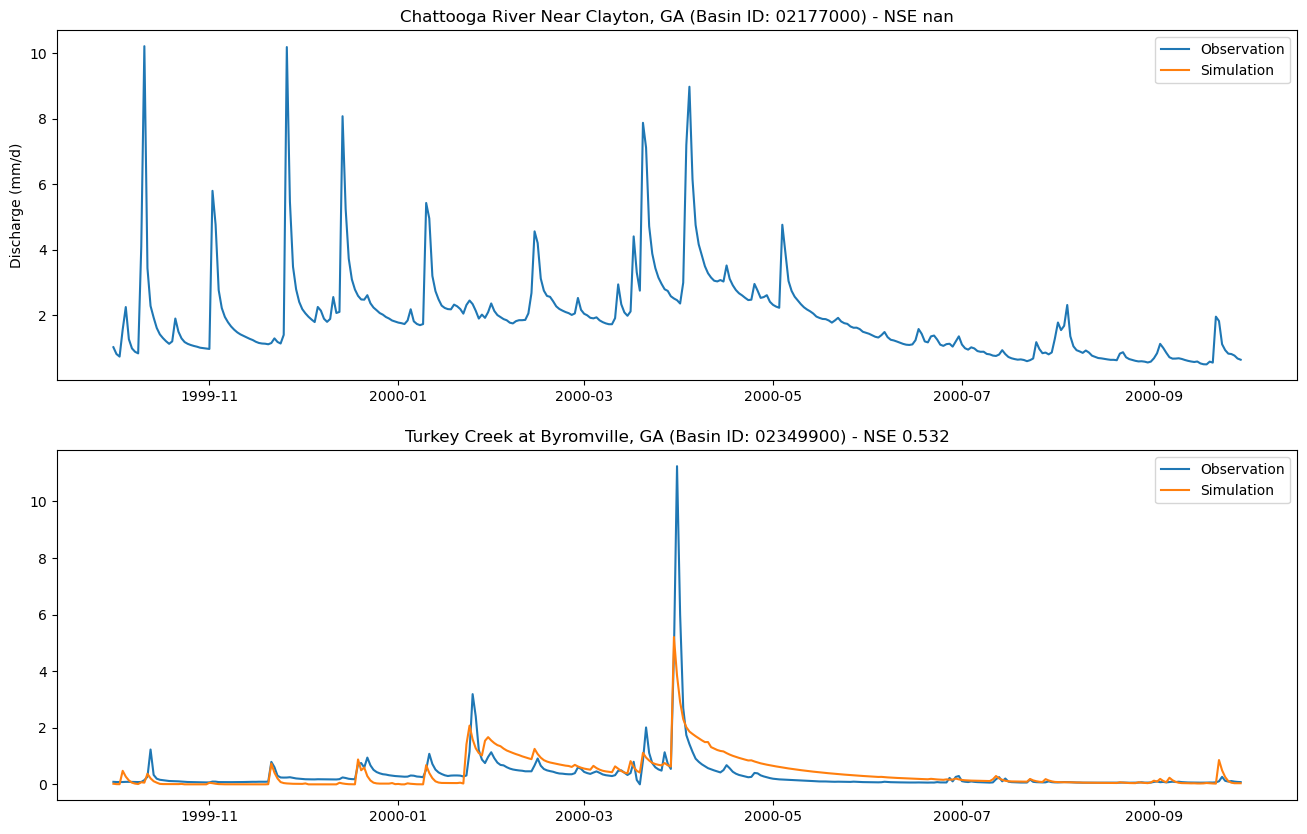

In [ ]:
from neuralhydrology.evaluation import metrics, get_tester
import pandas as pd
from neuralhydrology.utils.config import Config
import matplotlib.pyplot as plt

run_dir = Path("runs/DevMultiBasin_Test_1808_144049")
run_config = Config(run_dir / "config.yml")

# create a tester instance and start evaluation
tester = get_tester(cfg=Config(run_dir / "config.yml"), run_dir=run_dir, period="test", init_model=True)
results = tester.evaluate(save_results=True, metrics=run_config.metrics)

results.keys()


# Extract a date slice of observations and simulations
Result_xr_1 = results['02177000']['1D']['xr'].sel(date=slice("10-1999", None))

# Get the scalar date and the 1D array of time_step values
date_scalar_1 = Result_xr_1.coords['date'][0].values  # Extract as a NumPy scalar
time_step_values_1 = Result_xr_1.coords['time_step'].values  # Extract as NumPy array
# Broadcast the scalar date across time_step and add the timedelta
datetime_values_1 = date_scalar_1 + pd.to_timedelta(time_step_values_1, unit='D')

# Add the datetime as a new coordinate to Result_xr
Result_xr_1 = Result_xr_1.assign_coords(datetime=("time_step", datetime_values_1))

fig, ax = plt.subplots(2, 1, figsize=(16,10))

# Extract observations and simulations
qobs_1 = Result_xr_1['QObs_mm_per_day_obs']
qsim_1 = Result_xr_1['QObs_mm_per_day_sim']

result_NSE_1 = metrics.nse(qobs_1[0,:], qsim_1[0,:])
# Plot observations and simulations
ax[0].plot(Result_xr_1['datetime'], qobs_1[0,:], label="Observation")
ax[0].plot(Result_xr_1['datetime'], qsim_1[0,:], label="Simulation")
ax[0].set_ylabel("Discharge (mm/d)")
ax[0].set_title(f"Chattooga River Near Clayton, GA (Basin ID: 02177000) - NSE {result_NSE_1:.3f}")
_ = ax[0].legend()

# the other basin
# Extract a date slice of observations and simulations
Result_xr_2 = results['02349900']['1D']['xr'].sel(date=slice("10-1999", None))

# Get the scalar date and the 1D array of time_step values
date_scalar_2 = Result_xr_2.coords['date'][0].values  # Extract as a NumPy scalar
time_step_values_2 = Result_xr_2.coords['time_step'].values  # Extract as NumPy array

# Broadcast the scalar date across time_step and add the timedelta
datetime_values_2 = date_scalar_2 + pd.to_timedelta(time_step_values_2, unit='D')

# Add the datetime as a new coordinate to Result_xr
Result_xr_2 = Result_xr_2.assign_coords(datetime=("time_step", datetime_values_2))

# Extract observations and simulations
qobs_2 = Result_xr_2['QObs_mm_per_day_obs']
qsim_2 = Result_xr_2['QObs_mm_per_day_sim']

result_NSE_2 = metrics.nse(qobs_2[0,:], qsim_2[0,:])
# Plot observations and simulations
ax[1].plot(Result_xr_2['datetime'], qobs_2[0,:], label="Observation")
ax[1].plot(Result_xr_2['datetime'], qsim_2[0,:], label="Simulation")
ax[0].set_ylabel("Discharge (mm/d)")
ax[1].set_title(f"Turkey Creek at Byromville, GA (Basin ID: 02349900) - NSE {result_NSE_2:.3f}")
_ = ax[1].legend()
